In [3]:
import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.training.errors import ErrorDict
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.data.hamiltonian_dataset import seeded_random_split
from equiv_dens.utils.grids import cubical_grid, cubical_sampling,\
    dftpy_grid, CubicalGrid, spherical_grid, spherical_radial_sampling
from equiv_dens.training.model_loader import load_model
import equiv_dens.utils.base as utils
from equiv_dens.utils import orbitals
from functools import partial
import os
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
args, hyperparam_args = parse_command_line_arguments(arg_file='C_dens.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.verbose = 0
args.use_gpu = False
args.cube_grid = True
args.radii_adjust = True 
if args.cube_grid:
    args.cube_origin = -3
    args.cube_extent = 6
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=2)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

    
dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)
    
#dataset_df.density_fitting[0]['df_coeff'] *= 0
sample = dataset.get_properties([0])
sample_df = dataset_df.get_properties([0])
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(dataset_df.density_fitting)
print(dataset.atoms)
model = load_model(args, dataset)
result = model(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))


type dtype <class 'torch.dtype'>
args np dir datasets/C_augccpvdz.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg integral_constraint
loading hyperparam arg integral_scale
loading hyperparam arg in

dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
torch.Size([1, 125000])


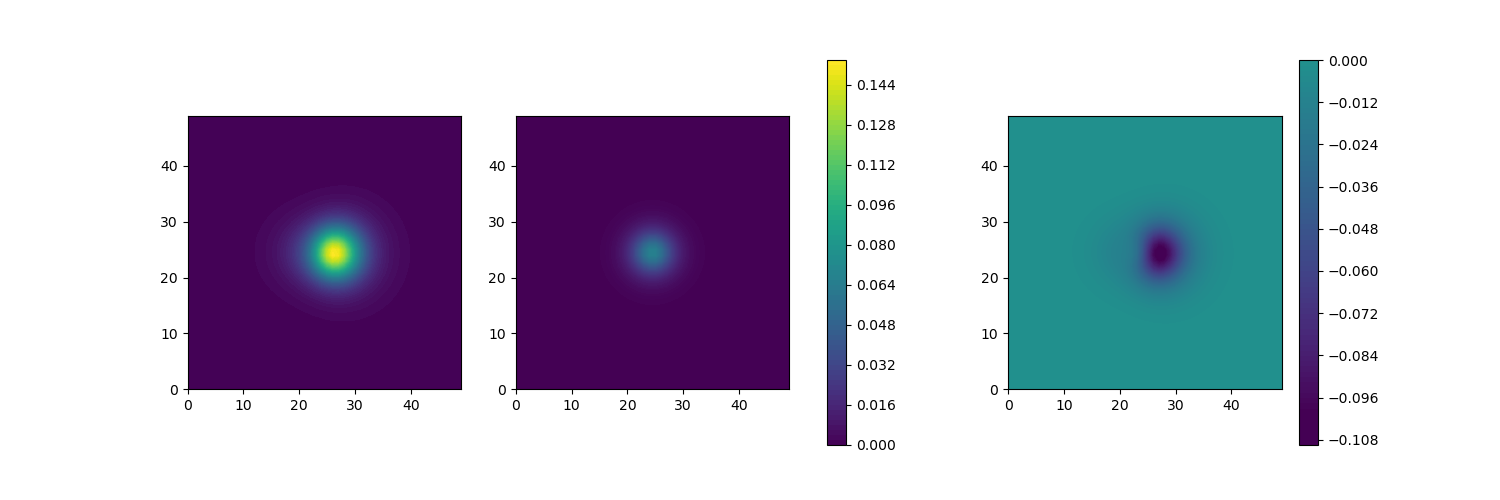

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
dens = np.array(sample['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = result['density'].cpu().data.squeeze().numpy()

p_dens = p_dens[idx].reshape(50, 50)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c1, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
torch.Size([1, 125000])


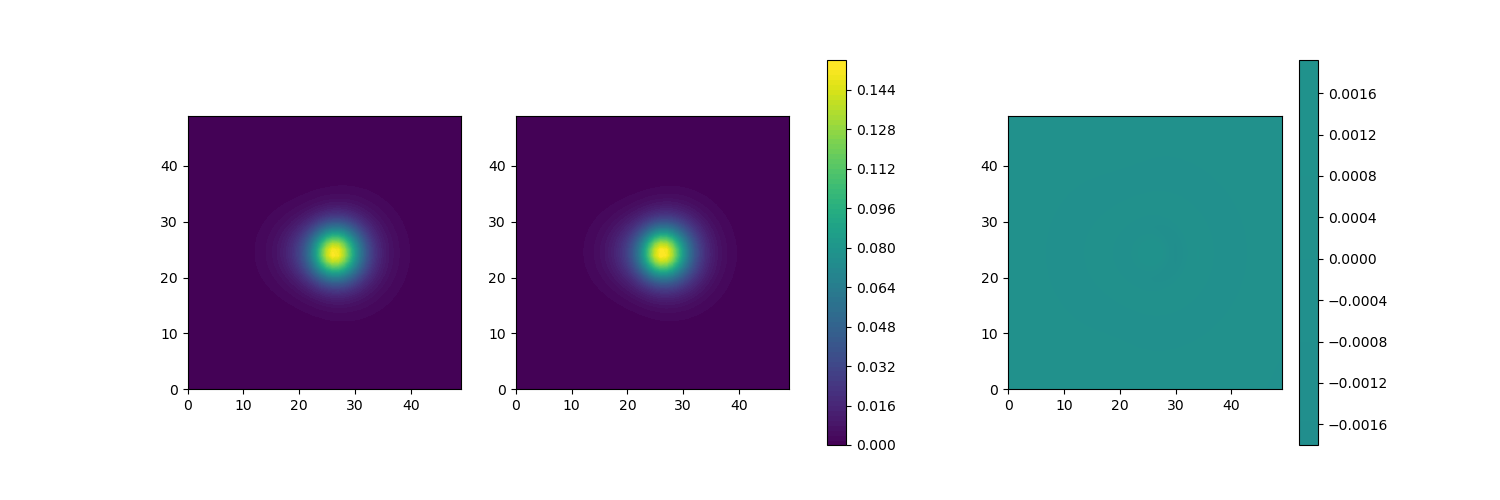

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
dens = np.array(sample['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = sample_df['density'].squeeze()

p_dens = p_dens[idx].reshape(50, 50)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

In [12]:
dataset.mols[0].atom_coords()

array([[0., 0., 0.]])

In [13]:
dataset_df.density_fitting[0]['df_coeff']

array([ 1.45228892e-01,  3.38316408e-01,  1.18358046e+00,  1.81938140e+00,
        2.26032592e+00,  5.94203008e-01, -2.69568021e-01,  4.59562409e-01,
        3.44423211e-01,  4.54919544e-02,  1.57038027e-03,  2.25591089e-13,
       -6.73282824e-15, -1.68620544e-13, -9.78703889e-13,  2.25016458e-13,
        1.19454596e-12, -1.52659660e-13,  2.71145092e-13,  7.60177247e-13,
       -1.66811994e-12,  1.75870793e-13,  1.49520490e-12,  6.21597390e-12,
       -1.33672024e-12, -7.56533702e-12,  6.30912502e-12, -1.19493509e-12,
       -6.84199837e-12, -1.98826307e-13, -7.82847989e-14,  2.57262787e-14,
       -3.48699826e-14,  2.57078536e-15,  3.26761699e-14, -1.19820734e-03,
        1.15169184e-03,  3.06046010e-03, -2.14007770e-02,  1.23390641e-02,
       -4.58056935e-03,  3.29156196e-03,  1.11800161e-02, -7.07157443e-02,
        4.25622339e-02, -6.02662531e-03,  6.73970944e-03,  1.58508549e-02,
       -1.17193847e-01,  6.60322973e-02, -2.98453258e-03,  3.58634119e-03,
        7.99014223e-03, -

In [14]:
ml_coeffs = orbitals.coeffs_dict_to_vector(result, model.density_repr_model[0].orbital_basis, result['atom_numbers'], radial_coeffs=False)
print(ml_coeffs)

{'spherical_coeffs': tensor([[0.1076, 0.0655, 0.6818, 0.8032, 0.5389, 0.0213, 2.0793, 0.0387, 0.2569,
         0.0652, 0.0030, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
       

In [15]:
dataset_df.density_fitting[0]['df_coeff'] = ml_coeffs['spherical_coeffs'].detach().cpu()
sample = dataset.get_properties(0)
sample_df = dataset_df.get_properties(0)
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(dataset_df.density_fitting)

density loss tensor([[0.6564]])
density integral tensor(5.4809)
df integral tensor(6.9670)
[{'df_coeff': tensor([[0.1076, 0.0655, 0.6818, 0.8032, 0.5389, 0.0213, 2.0793, 0.0387, 0.2569,
         0.0652, 0.0030, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
    

In [16]:
print(result['radial_width'])
print(result['radial_scale'])

[{(6, 0): tensor([[[[-0.8105,  0.9723, -0.3463, -0.9801,  0.9919, -1.0000,  0.0533,
           -0.9999, -0.9999,  0.9974,  0.9968]]]], grad_fn=<CopySlices>), (6, 1): tensor([[[[ 0.1374,  0.9936, -0.6942, -0.8183,  0.7928, -0.5466,  0.4707,
            0.8917]]]], grad_fn=<CopySlices>), (6, 2): tensor([[[[ 0.9104, -0.9071, -0.0944,  0.5264,  0.4053, -0.0602]]]],
       grad_fn=<CopySlices>), (6, 3): tensor([[[[-0.6955,  0.9778, -0.6555, -0.9215]]]], grad_fn=<CopySlices>), (6, 4): tensor([[[[-0.0976,  0.4720, -0.9398]]]], grad_fn=<CopySlices>), (6, 5): tensor([[[[-0.9876, -0.0130]]]], grad_fn=<CopySlices>)}]
[{(6, 0): tensor([[[[2.7105, 0.0391, 0.2027, 0.4063, 0.0386, 0.1981, 0.1730, 0.0155,
           0.1622, 0.0855, 0.3254]]]], grad_fn=<CopySlices>), (6, 1): tensor([[[[0.5199, 0.4515, 1.1012, 1.0183, 0.6294, 1.1583, 1.1753, 0.4460]]]],
       grad_fn=<CopySlices>), (6, 2): tensor([[[[2.0061, 1.6126, 0.4650, 0.6725, 1.3094, 0.1517]]]],
       grad_fn=<CopySlices>), (6, 3): tensor([[[[0.

In [17]:
109.4367/5.4809

19.966921490996004

In [36]:
dataset_df.density_fitting[0]['df_coeff'] *= 0
print(dataset_df.density_fitting[0]['df_coeff'].shape)
dataset_df.density_fitting[0]['df_coeff'][:, 6] = 1
print(dataset_df.density_fitting[0]['df_coeff'])

sample_df = dataset_df.get_properties(0)
df_integral =  torch.sum(sample_df['density'] * sample['coord_weights'])
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))

torch.Size([1, 142])
tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
df integral tensor(1.8748)


In [37]:
coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': dataset_df.density_fitting[0]['df_coeff']}, model.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:result['radial_width'][i][key]*0 for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:result['radial_scale'][i][key]*0 for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
#sample['radial_scale'] = result['radial_scale']
print('radial width', sample['radial_width'])
res = model.property_models['density'](sample)

ml_integral = torch.sum(res['density'] * sample['coord_weights'])
print('ml integral', torch.sum(res['density'] * sample['coord_weights']))
ratio = ml_integral/df_integral
print('ratio', ratio)

radial width [{(6, 0): tensor([[[[-0., 0., -0., -0., 0., -0., 0., -0., -0., 0., 0.]]]],
       grad_fn=<MulBackward0>), (6, 1): tensor([[[[0., 0., -0., -0., 0., -0., 0., 0.]]]], grad_fn=<MulBackward0>), (6, 2): tensor([[[[0., -0., -0., 0., 0., -0.]]]], grad_fn=<MulBackward0>), (6, 3): tensor([[[[-0., 0., -0., -0.]]]], grad_fn=<MulBackward0>), (6, 4): tensor([[[[-0., 0., -0.]]]], grad_fn=<MulBackward0>), (6, 5): tensor([[[[-0., -0.]]]], grad_fn=<MulBackward0>)}]
density expansion time: 0.0782768726348877
ml integral tensor(0.9412, grad_fn=<SumBackward0>)
ratio tensor(0.5020, grad_fn=<DivBackward0>)


In [90]:
print(np.sqrt(1/(4*np.pi)))

0.28209479177387814
